# ML1 – Lab Test 2: Unsupervised Learning — Customer Segmentation

**Group members:** Menad Ammour 

## Setup — Import Libraries

In [99]:
# Core libraries
import os
import warnings
from pathlib import Path

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and dimensionality reduction
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Clustering algorithms
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors

# Clustering evaluation metrics
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Hierarchical clustering tools
from scipy.cluster.hierarchy import dendrogram, linkage

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot configuration
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

## Setup — Load Dataset

In [100]:
# Load the dataset
df = pd.read_csv("Wholesale customers data.csv")

# Display basic information
print("Dataset loaded successfully.")
display(df.head())
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nData types:")
display(df.dtypes)

Dataset loaded successfully.


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


Shape: (440, 8)
Columns: ['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

Data types:


Channel             int64
Region              int64
Fresh               int64
Milk                int64
Grocery             int64
Frozen              int64
Detergents_Paper    int64
Delicassen          int64
dtype: object

# PART 1 — Exploratory Data Analysis (EDA)

In [101]:
# Identify the spending feature columns.
expected_spending_features = [
    "Fresh", "Milk", "Grocery", "Frozen", "Detergents_Paper", "Delicatessen", "Delicassen"
]
spending_features = [col for col in expected_spending_features if col in df.columns]

if len(spending_features) != 6:
    raise ValueError(f"Expected 6 spending features, but found {len(spending_features)}: {spending_features}")

non_spending_columns = [col for col in df.columns if col not in spending_features]

print("Spending features used for analysis:", spending_features)
print("Non-spending columns detected:", non_spending_columns)

Spending features used for analysis: ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
Non-spending columns detected: ['Channel', 'Region']


In [102]:
# Summary statistics for all columns
display(df.describe().T)

# Summary statistics only for spending variables
display(df[spending_features].describe().T)

,count,mean,std,min,25%,50%,75%,max
Channel,440.0,1.322727,0.468052,1.0,1.00,1.0,2.00,2.0
Region,440.0,2.543182,0.774272,1.0,2.00,3.0,3.00,3.0
Fresh,440.0,12000.297727,12647.328865,3.0,3127.75,8504.0,16933.75,112151.0
Milk,440.0,5796.265909,7380.377175,55.0,1533.00,3627.0,7190.25,73498.0
Grocery,440.0,7951.277273,9503.162829,3.0,2153.00,4755.5,10655.75,92780.0
Frozen,440.0,3071.931818,4854.673333,25.0,742.25,1526.0,3554.25,60869.0
Detergents_Paper,440.0,2881.493182,4767.854448,3.0,256.75,816.5,3922.00,40827.0
Delicassen,440.0,1524.870455,2820.105937,3.0,408.25,965.5,1820.25,47943.0


,count,mean,std,min,25%,50%,75%,max
Fresh,440.0,12000.297727,12647.328865,3.0,3127.75,8504.0,16933.75,112151.0
Milk,440.0,5796.265909,7380.377175,55.0,1533.00,3627.0,7190.25,73498.0
Grocery,440.0,7951.277273,9503.162829,3.0,2153.00,4755.5,10655.75,92780.0
Frozen,440.0,3071.931818,4854.673333,25.0,742.25,1526.0,3554.25,60869.0
Detergents_Paper,440.0,2881.493182,4767.854448,3.0,256.75,816.5,3922.00,40827.0
Delicassen,440.0,1524.870455,2820.105937,3.0,408.25,965.5,1820.25,47943.0


In [103]:
# Missing values and duplicates
missing_values = df.isnull().sum().to_frame("Missing Values")
duplicates_count = df.duplicated().sum()

print("Missing values per column:")
display(missing_values)

print(f"Number of duplicate rows: {duplicates_count}")

Missing values per column:


,Missing Values
Channel,0
Region,0
Fresh,0
Milk,0
Grocery,0
Frozen,0
Detergents_Paper,0
Delicassen,0


Number of duplicate rows: 0


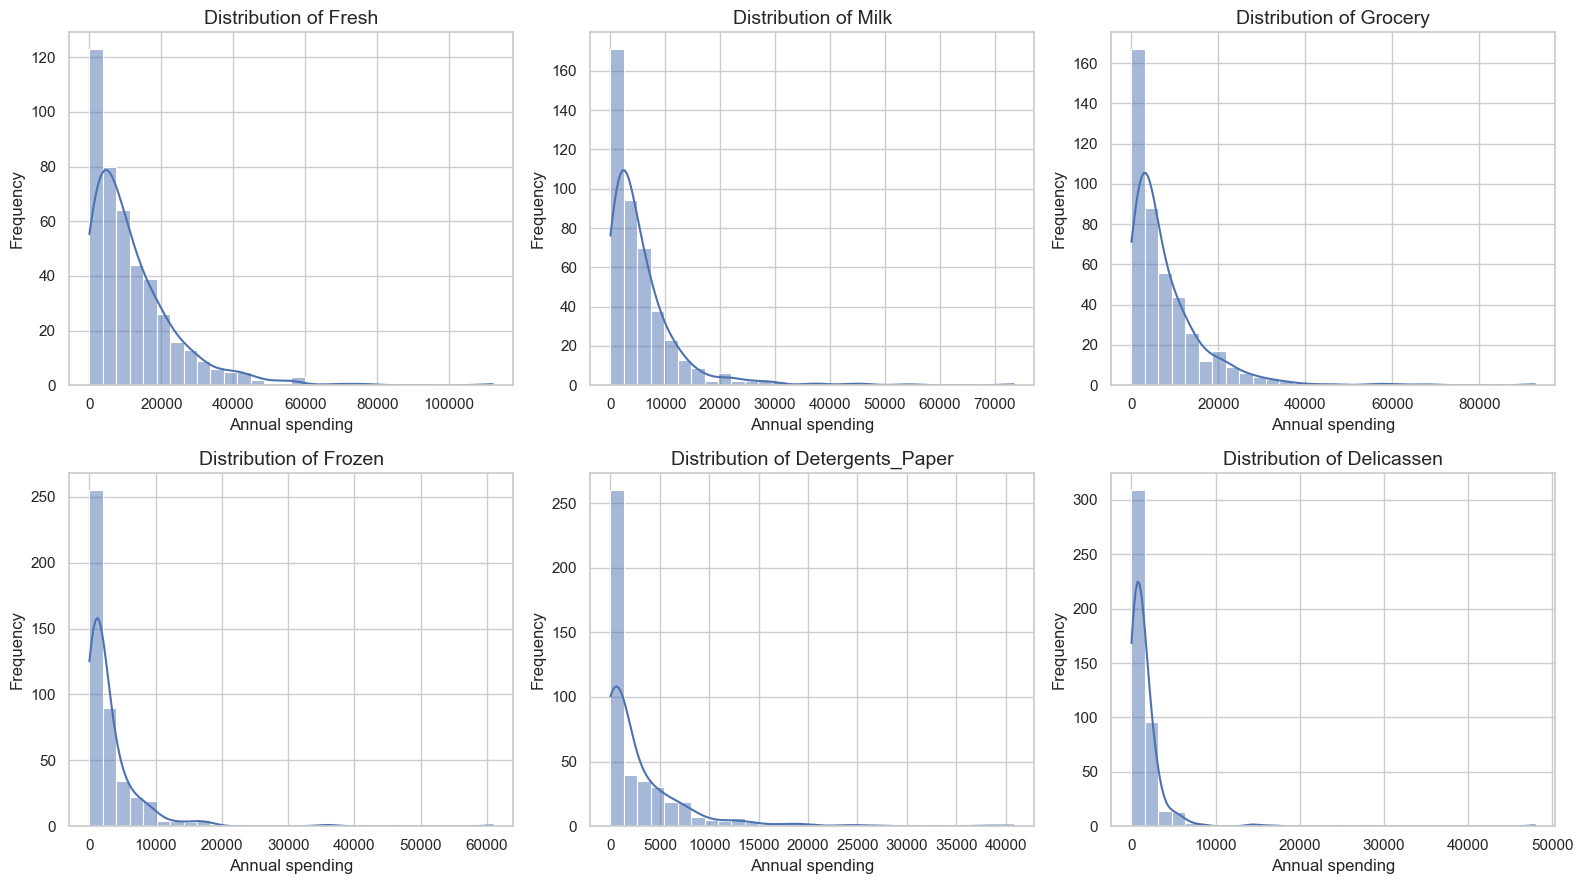

In [104]:
# Histograms: distribution of each spending feature
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, spending_features):
    sns.histplot(df[col], kde=True, bins=30, ax=ax, color="C0")
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel("Annual spending")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

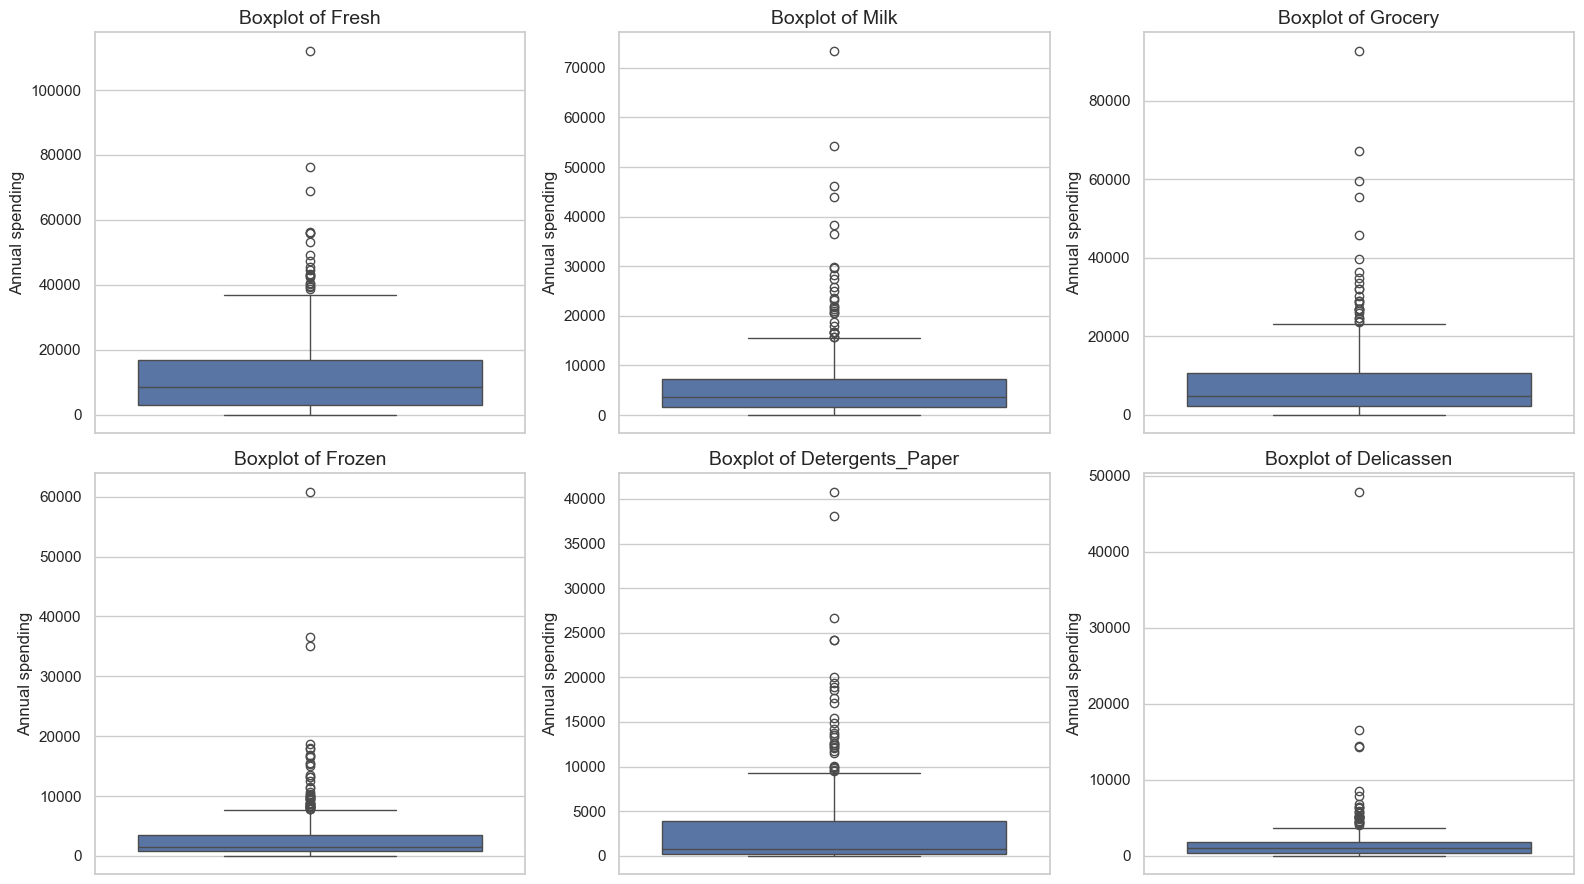

In [105]:
# Boxplots: useful to visually inspect outliers
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, spending_features):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(f"Boxplot of {col}")
    ax.set_ylabel("Annual spending")

plt.tight_layout()
plt.show()

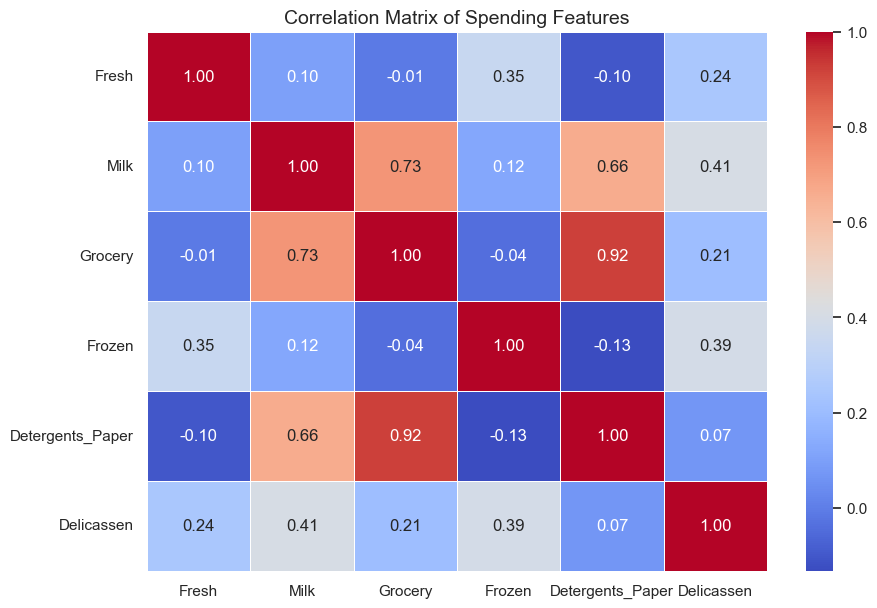

In [106]:
# Correlation matrix heatmap
corr_matrix = df[spending_features].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Spending Features")
plt.show()

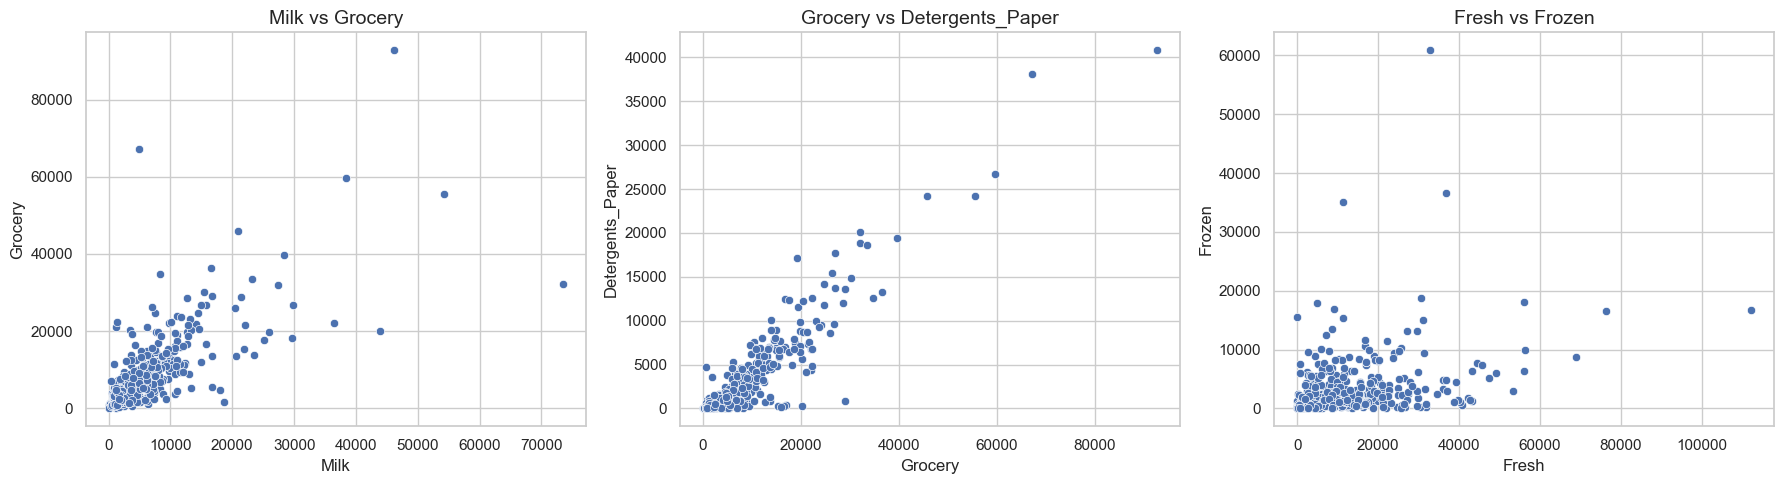

In [107]:
# Selected scatterplots to inspect relationships between important spending categories
selected_pairs = [("Milk", "Grocery"), ("Grocery", "Detergents_Paper"), ("Fresh", "Frozen")]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (x_col, y_col) in zip(axes, selected_pairs):
    if x_col in df.columns and y_col in df.columns:
        sns.scatterplot(data=df, x=x_col, y=y_col, ax=ax)
        ax.set_title(f"{x_col} vs {y_col}")

plt.tight_layout()
plt.show()

In [108]:
# Skewness check
skewness = df[spending_features].skew().sort_values(ascending=False).to_frame("Skewness")
display(skewness)

,Skewness
Delicassen,11.151586
Frozen,5.907986
Milk,4.053755
Detergents_Paper,3.631851
Grocery,3.587429
Fresh,2.561323


In [109]:
# Outlier detection using the IQR rule on raw spending variables
outlier_summary = []
outlier_masks = pd.DataFrame(index=df.index)

for col in spending_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    mask = (df[col] < lower_bound) | (df[col] > upper_bound)
    outlier_masks[col] = mask
    outlier_summary.append({
        "Feature": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": int(mask.sum()),
        "Outlier %": round(mask.mean() * 100, 2)
    })

outlier_summary_df = pd.DataFrame(outlier_summary)
display(outlier_summary_df)

rows_with_any_outlier = outlier_masks.any(axis=1).sum()
print(f"Rows with at least one outlier: {rows_with_any_outlier} / {len(df)}")

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,Fresh,3127.75,16933.75,13806.00,-17581.250,37642.750,20,4.55
1,Milk,1533.00,7190.25,5657.25,-6952.875,15676.125,28,6.36
2,Grocery,2153.00,10655.75,8502.75,-10601.125,23409.875,24,5.45
3,Frozen,742.25,3554.25,2812.00,-3475.750,7772.250,43,9.77
4,Detergents_Paper,256.75,3922.00,3665.25,-5241.125,9419.875,30,6.82
5,Delicassen,408.25,1820.25,1412.00,-1709.750,3938.250,27,6.14


Rows with at least one outlier: 108 / 440


## PART 1 — Exploratory Data Analysis (EDA)

### 1. What is the size of the dataset?

The dataset contains **440 rows** and **8 columns**.

Dataset shape:

**(440, 8)**

Each row represents one customer, and each column represents either a customer category variable or an annual spending variable.

### 2. What are the types of variables?

All variables in the dataset are stored as integer values.

The dataset contains two non-spending columns:

- **Channel**
- **Region**

These variables are categorical/identifier-type variables.

The main spending features are:

- **Fresh**
- **Milk**
- **Grocery**
- **Frozen**
- **Detergents_Paper**
- **Delicassen**

These features represent the annual spending of each customer in different product categories.

### 3. Are there missing values?

No, there are **no missing values** in the dataset.

The missing value check showed **0 missing values in all columns**, so no imputation was needed.

### 4. Are there outliers?

Yes, the dataset contains outliers.

Using the IQR method, the number of outliers detected in each spending feature was:

| Feature | Number of outliers |
|---|---:|
| Fresh | 20 |
| Milk | 28 |
| Grocery | 24 |
| Frozen | 43 |
| Detergents_Paper | 30 |
| Delicassen | 27 |

In total, **108 out of 440 rows** had at least one outlier.

This shows that the dataset contains several customers with unusually high spending in one or more product categories. Since this is spending data, these outliers may represent real important customers, so they should not be deleted directly without careful treatment.

### 5. What are the distributions of the variables?

The histograms and skewness values show that all spending variables are **right-skewed**.

The skewness values were:

| Feature | Skewness |
|---|---:|
| Delicassen | 11.151586 |
| Frozen | 5.907986 |
| Milk | 4.053755 |
| Detergents_Paper | 3.631851 |
| Grocery | 3.587429 |
| Fresh | 2.561323 |

This means that most customers spend relatively small or moderate amounts, while a smaller number of customers spend very high amounts.

The most skewed variable is **Delicassen**, followed by **Frozen** and **Milk**.

Because of this strong skewness, a log transformation was useful before clustering.

### 6. Are some features correlated?

Yes, some features are strongly correlated.

The most important correlations are:

| Feature pair | Correlation |
|---|---:|
| Grocery and Detergents_Paper | 0.92 |
| Milk and Grocery | 0.73 |
| Milk and Detergents_Paper | 0.66 |
| Fresh and Frozen | 0.35 |
| Fresh and Grocery | approximately -0.01 |

The strongest relationship is between **Grocery** and **Detergents_Paper**, with a correlation of **0.92**. This means that customers who spend more on Grocery also tend to spend more on Detergents_Paper.

Milk is also strongly related to Grocery and Detergents_Paper, which suggests that these products may form a similar customer purchasing pattern.

Fresh is almost not correlated with Grocery, which means Fresh spending may represent a different type of customer behavior.

### 7. Which features seem most important for segmentation?

The most important features for segmentation appear to be:

- **Grocery**
- **Detergents_Paper**
- **Milk**
- **Fresh**
- **Frozen**

Grocery, Milk, and Detergents_Paper are important because they are strongly correlated and help identify customers who spend more on retail-type products.

Fresh and Frozen are also important because they show a different spending pattern and help separate customers who focus more on fresh and frozen products.

Delicassen is also useful, but it is highly skewed and contains strong outliers, so it should be handled carefully.

---

# PART 2 — Data Preprocessing

In [110]:
# Select only spending features for clustering.
# Channel and Region are categorical/identifier-type variables, so they are excluded from the main clustering pipeline.
X_raw = df[spending_features].copy()

print("Features used for clustering:", X_raw.columns.tolist())
print("Excluded columns:", non_spending_columns)

display(X_raw.head())

Features used for clustering: ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
Excluded columns: ['Channel', 'Region']


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,12669,9656,7561,214,2674,1338
1,7057,9810,9568,1762,3293,1776
2,6353,8808,7684,2405,3516,7844
3,13265,1196,4221,6404,507,1788
4,22615,5410,7198,3915,1777,5185


In [111]:
# Log transformation reduces the effect of strong right skew in spending variables.
X_log = np.log1p(X_raw)

# Compare skewness before and after log transformation
skew_comparison = pd.DataFrame({
    "Raw Skewness": X_raw.skew(),
    "Log1p Skewness": X_log.skew()
}).sort_values("Raw Skewness", ascending=False)

display(skew_comparison)

,Raw Skewness,Log1p Skewness
Delicassen,11.151586,-1.091827
Frozen,5.907986,-0.352655
Milk,4.053755,-0.224063
Detergents_Paper,3.631851,-0.235961
Grocery,3.587429,-0.674938
Fresh,2.561323,-1.575326


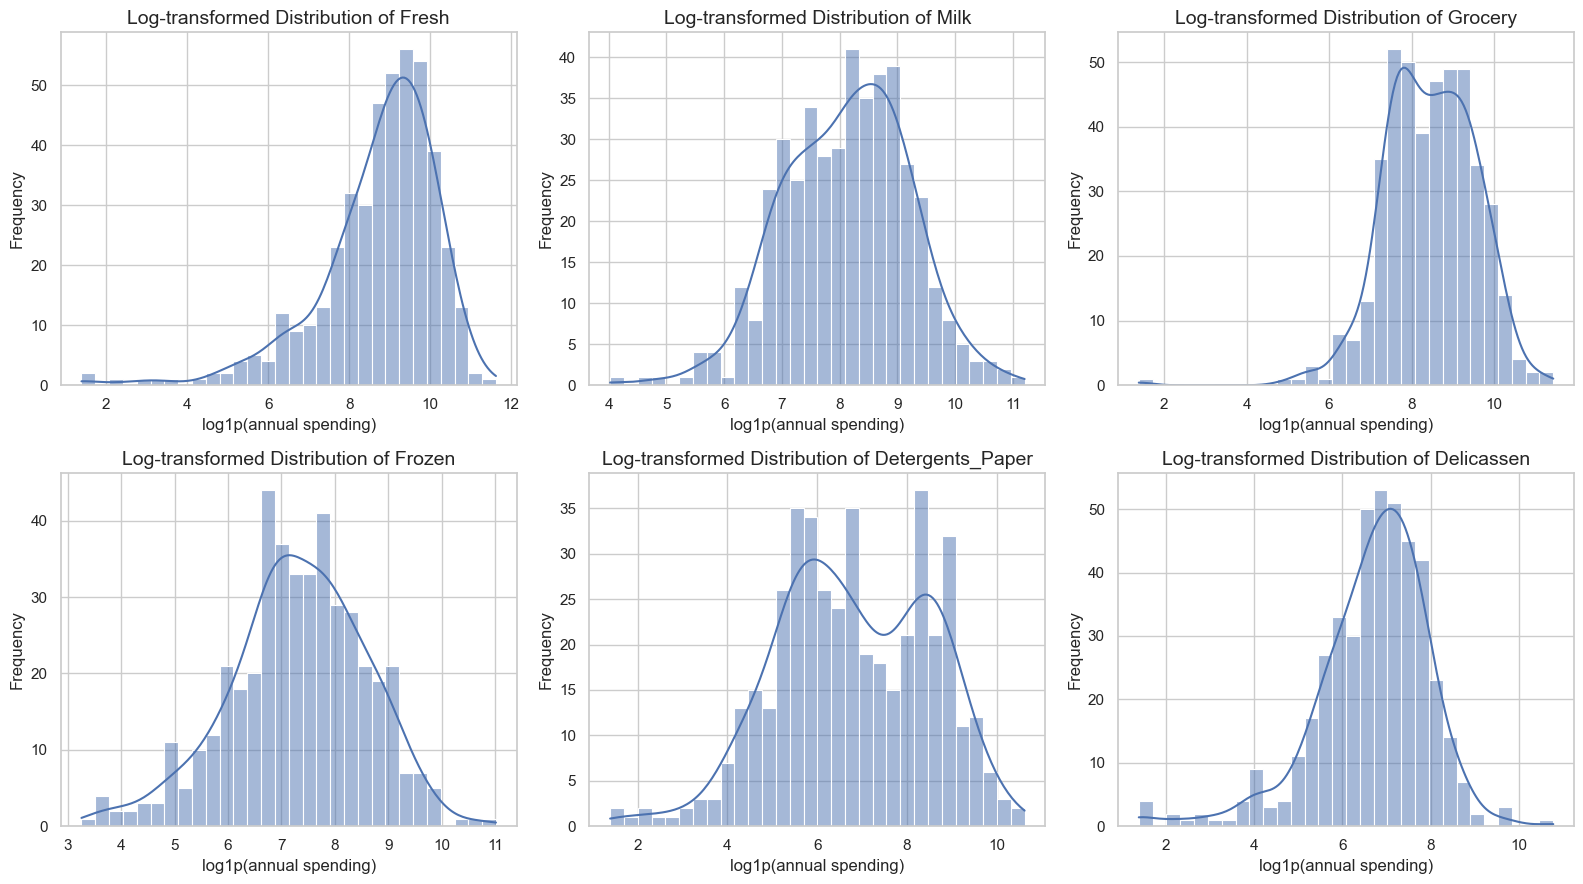

In [112]:
# Visualize transformed distributions
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, spending_features):
    sns.histplot(X_log[col], kde=True, bins=30, ax=ax, color="C0")
    ax.set_title(f"Log-transformed Distribution of {col}")
    ax.set_xlabel("log1p(annual spending)")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [113]:
# Handle extreme outliers carefully by clipping on the log-transformed data.
# This keeps all customers while reducing the influence of extreme values.
# We use a wider IQR multiplier (3.0) to only treat extreme points.
X_log_clipped = X_log.copy()
extreme_outlier_summary = []

for col in spending_features:
    Q1 = X_log[col].quantile(0.25)
    Q3 = X_log[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 3.0 * IQR
    upper_bound = Q3 + 3.0 * IQR
    before_clip = X_log[col].copy()
    X_log_clipped[col] = X_log[col].clip(lower=lower_bound, upper=upper_bound)
    clipped_count = int((before_clip != X_log_clipped[col]).sum())
    extreme_outlier_summary.append({
        "Feature": col,
        "Extreme Lower Bound (log)": lower_bound,
        "Extreme Upper Bound (log)": upper_bound,
        "Clipped Values": clipped_count
    })

extreme_outlier_summary_df = pd.DataFrame(extreme_outlier_summary)
display(extreme_outlier_summary_df)

,Feature,Extreme Lower Bound (log),Extreme Upper Bound (log),Clipped Values
0,Fresh,2.982145,14.803357,4
1,Milk,2.700676,13.515577,0
2,Grocery,2.878480,14.070548,1
3,Frozen,1.915564,12.871637,0
4,Detergents_Paper,-2.615832,16.442416,0
5,Delicassen,1.535452,11.986147,4


In [114]:
# Scaling is necessary because clustering algorithms use distances.
# RobustScaler is chosen because the dataset contains outliers even after log transformation.
scaler = RobustScaler()
X_processed_array = scaler.fit_transform(X_log_clipped)
X_processed = pd.DataFrame(X_processed_array, columns=spending_features, index=df.index)

print("Processed dataset shape:", X_processed.shape)
display(X_processed.head())

Processed dataset shape: (440, 6)


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0.236027,0.633665,0.289970,-1.252532,0.435415,0.218358
1,-0.110429,0.643905,0.437195,0.091831,0.511868,0.407917
2,-0.172651,0.574176,0.300061,0.290501,0.535928,1.402554
3,0.263246,-0.717716,-0.074555,0.916071,-0.174744,0.412425
4,0.579134,0.258743,0.259202,0.601719,0.285389,1.125309


In [115]:
# Store a clean working dataframe for later labels and profiles
analysis_df = df.copy()


## PART 2 — Data Preprocessing

### 1. Why is feature scaling necessary in this dataset?

Feature scaling is necessary because clustering algorithms such as K-Means, DBSCAN, and Hierarchical Clustering use distances between data points.

In this dataset, the spending values have very different ranges. Without scaling, features with larger numerical values would dominate the distance calculation and have too much influence on the clustering result.

Scaling makes all features comparable and allows the clustering algorithms to treat each spending category more fairly.

### 2. Apply an appropriate scaling method and justify your choice.

The preprocessing used three main steps.

First, only the spending features were selected:

- **Fresh**
- **Milk**
- **Grocery**
- **Frozen**
- **Detergents_Paper**
- **Delicassen**

The columns **Channel** and **Region** were excluded because they are non-spending/categorical variables.

Second, a **log transformation using `np.log1p`** was applied. This was necessary because the spending variables were strongly right-skewed. The log transformation reduced the effect of very large spending values and made the distributions more balanced.

Third, **RobustScaler** was applied. RobustScaler was a good choice because the dataset contains many outliers. Unlike StandardScaler, RobustScaler uses the median and interquartile range, so it is less affected by extreme values.

The final processed dataset had shape:

**(440, 6)**

### 3. Do you detect extreme outliers? How do you handle them?

Yes, extreme outliers were detected.

Instead of deleting these customers, the notebook handled them carefully by clipping extreme values after the log transformation. A wider IQR multiplier of **3.0** was used, so only very extreme values were clipped.

The number of clipped values was:

| Feature | Clipped values |
|---|---:|
| Fresh | 4 |
| Milk | 0 |
| Grocery | 1 |
| Frozen | 0 |
| Detergents_Paper | 0 |
| Delicassen | 4 |

This approach keeps all **440 customers** in the dataset while reducing the influence of extreme values on the clustering algorithms.

### 4. Should all features be kept? Why?

All six spending features were kept because each one represents a different type of customer purchasing behavior.

However, **Channel** and **Region** were excluded from the clustering process because they are categorical/non-spending variables. The goal of the project is to segment customers based on annual spending behavior, so the six spending variables are the most relevant features.

Even though some variables are correlated, such as Grocery and Detergents_Paper, they were kept because they still provide useful information about the customer profile.

---

# PART 3 — Clustering with K-Means

In [116]:
# Test different values of K using inertia and silhouette score
k_values = range(2, 11)
inertias = []
silhouette_scores_kmeans = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X_processed)
    inertias.append(kmeans.inertia_)
    silhouette_scores_kmeans.append(silhouette_score(X_processed, labels))

kmeans_scores_df = pd.DataFrame({
    "K": list(k_values),
    "Inertia": inertias,
    "Silhouette Score": silhouette_scores_kmeans
})

display(kmeans_scores_df)

,K,Inertia,Silhouette Score
0,2,1146.900110,0.253846
1,3,931.158330,0.244581
2,4,828.820785,0.198031
3,5,760.561030,0.185981
4,6,697.302203,0.193661
5,7,651.473670,0.177000
6,8,607.292741,0.186466
7,9,578.387608,0.188304
8,10,554.249305,0.182388


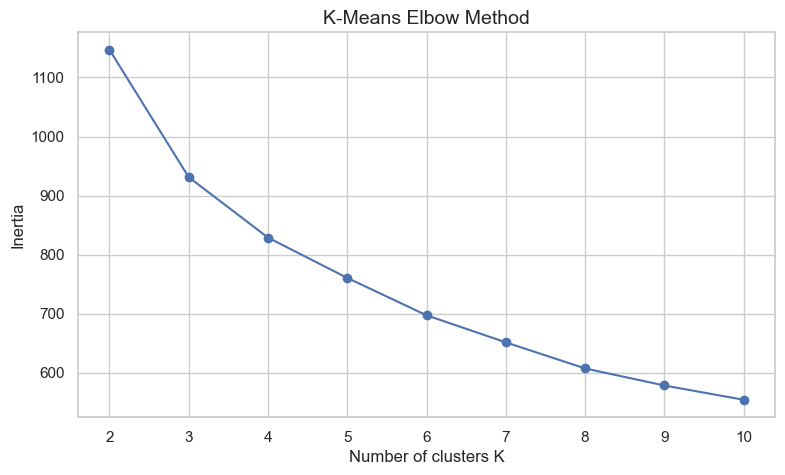

In [117]:
# Elbow Method plot
plt.figure(figsize=(9, 5))
plt.plot(kmeans_scores_df["K"], kmeans_scores_df["Inertia"], marker="o")
plt.title("K-Means Elbow Method")
plt.xlabel("Number of clusters K")
plt.ylabel("Inertia")
plt.xticks(list(k_values))
plt.show()

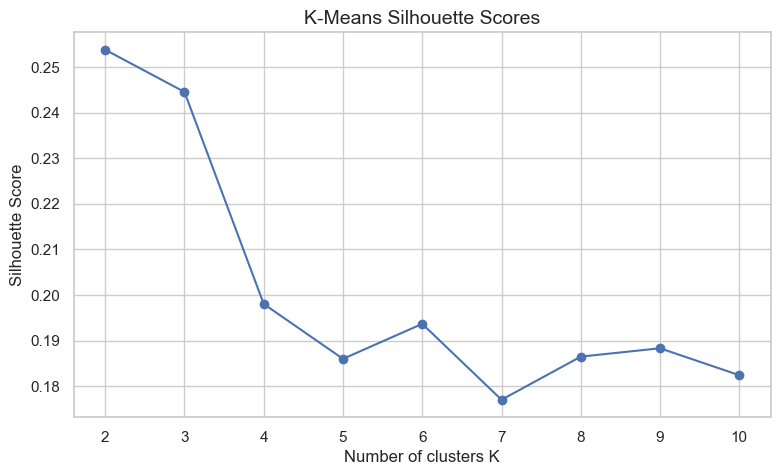

In [118]:
# Silhouette Score plot for K-Means
plt.figure(figsize=(9, 5))
plt.plot(kmeans_scores_df["K"], kmeans_scores_df["Silhouette Score"], marker="o")
plt.title("K-Means Silhouette Scores")
plt.xlabel("Number of clusters K")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_values))
plt.show()

In [119]:
# Select optimal K based on the highest silhouette score.
optimal_k = int(kmeans_scores_df.loc[kmeans_scores_df["Silhouette Score"].idxmax(), "K"])
print("Optimal K selected from silhouette score:", optimal_k)

# Fit final K-Means model
kmeans_final = KMeans(n_clusters=optimal_k, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_processed)
analysis_df["KMeans_Cluster"] = kmeans_labels

print("K-Means cluster counts:")
display(analysis_df["KMeans_Cluster"].value_counts().sort_index().to_frame("Count"))

Optimal K selected from silhouette score: 2
K-Means cluster counts:


,Count
KMeans_Cluster,
0,252
1,188


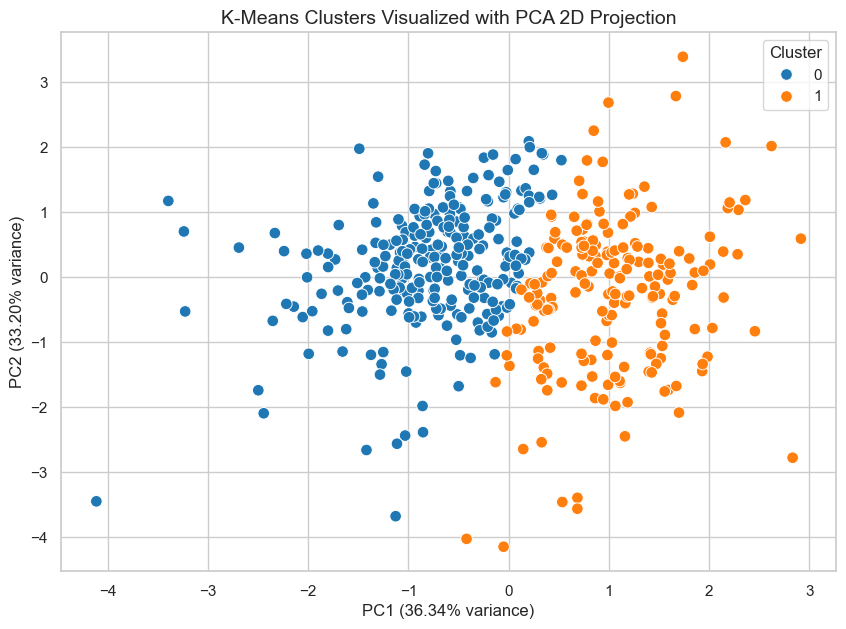

In [120]:
# PCA 2D projection for visualization
pca_2d_model = PCA(n_components=2, random_state=RANDOM_STATE)
pca_2d = pca_2d_model.fit_transform(X_processed)

pca_plot_df = pd.DataFrame(pca_2d, columns=["PC1", "PC2"], index=df.index)
pca_plot_df["KMeans_Cluster"] = kmeans_labels

plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_plot_df, x="PC1", y="PC2", hue="KMeans_Cluster", palette="tab10", s=70)
plt.title("K-Means Clusters Visualized with PCA 2D Projection")
plt.xlabel(f"PC1 ({pca_2d_model.explained_variance_ratio_[0]*100:.2f}% variance)")
plt.ylabel(f"PC2 ({pca_2d_model.explained_variance_ratio_[1]*100:.2f}% variance)")
plt.legend(title="Cluster")
plt.show()

In [121]:
# Approximate K-Means cluster centers in original spending scale.
centers_log = scaler.inverse_transform(kmeans_final.cluster_centers_)
centers_original = np.expm1(centers_log)

kmeans_centers_original_df = pd.DataFrame(
    centers_original,
    columns=spending_features
)
kmeans_centers_original_df.index.name = "KMeans_Cluster"

display(kmeans_centers_original_df.round(2))

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
KMeans_Cluster,,,,,,
0,8720.49,1755.76,2323.78,2136.53,294.03,622.54
1,4010.34,8048.90,11802.37,910.27,3913.90,1084.93


In [122]:
# Cluster profile table using real average spending values
kmeans_profile = analysis_df.groupby("KMeans_Cluster")[spending_features].mean().round(2)
kmeans_profile["Cluster Size"] = analysis_df["KMeans_Cluster"].value_counts().sort_index()

display(kmeans_profile)

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Cluster Size
KMeans_Cluster,,,,,,,
0,14065.92,2416.86,3010.48,3787.68,520.42,1008.25,252
1,9231.49,10326.11,14574.05,2112.52,6046.34,2217.36,188


## PART 3 — Clustering with K-Means

### 1. Briefly explain how K-Means works.

K-Means is a centroid-based clustering algorithm.

It works by choosing a number of clusters, called **K**, and then assigning each customer to the nearest cluster center. After that, the algorithm updates the cluster centers based on the average position of the assigned customers.

This process repeats until the cluster assignments become stable.

The goal of K-Means is to create clusters where customers inside the same cluster are similar to each other, and customers in different clusters are as different as possible.

### 2. How do you choose the number of clusters K?

The number of clusters K was chosen using two methods:

- **Elbow Method**
- **Silhouette Score**

The Elbow Method checks how the inertia decreases as K increases. Inertia measures how compact the clusters are. A good K is often found where the decrease in inertia starts to slow down.

The Silhouette Score measures how well-separated the clusters are. A higher silhouette score means better separation between clusters.

### 3. Explain the Elbow Method and Silhouette Score results.

The K-Means results were:

| K | Inertia | Silhouette Score |
|---:|---:|---:|
| 2 | 1146.900110 | 0.253846 |
| 3 | 931.158330 | 0.244581 |
| 4 | 828.820785 | 0.198031 |
| 5 | 760.561030 | 0.185981 |
| 6 | 697.302203 | 0.193661 |
| 7 | 651.473670 | 0.177000 |
| 8 | 607.292741 | 0.186466 |
| 9 | 578.387608 | 0.188304 |
| 10 | 554.249305 | 0.182388 |

The inertia decreases as K increases, which is expected. However, the improvement becomes smaller after the first few values of K.

The highest silhouette score was obtained for **K = 2**, with a score of **0.253846**. This means that 2 clusters gave the best separation among the tested K values.

### 4. What is the optimal value of K? Justify.

The optimal value selected for K-Means was:

**K = 2**

This was selected because it had the highest silhouette score among the tested values.

The K-Means cluster counts were:

| Cluster | Number of customers |
|---|---:|
| Cluster 0 | 252 |
| Cluster 1 | 188 |

The cluster profile showed that:

- **Cluster 0** has higher Fresh spending and lower Milk, Grocery, and Detergents_Paper spending.
- **Cluster 1** has higher Milk, Grocery, Detergents_Paper, and Delicassen spending.

So, K-Means produced two meaningful customer groups based on spending behavior.

---

# PART 4 — Clustering with DBSCAN

min_samples selected: 12


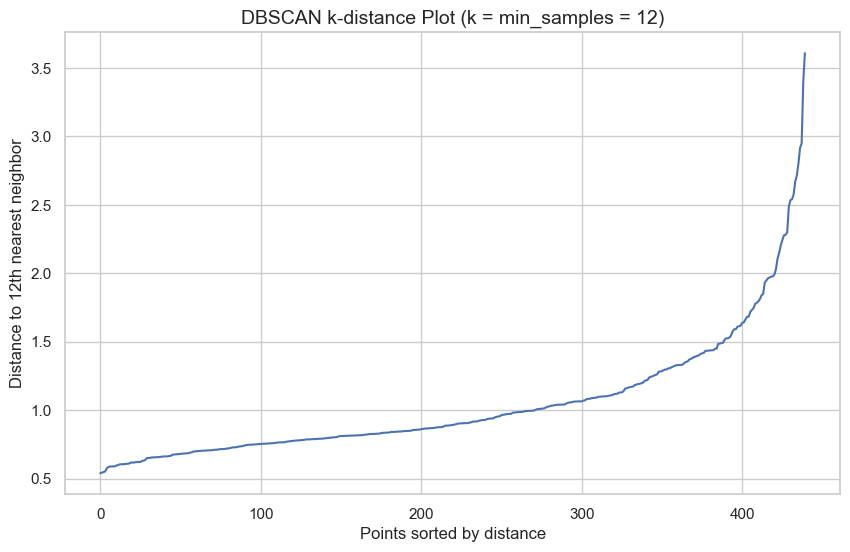

In [123]:
# DBSCAN requires eps and min_samples.
# A common starting point for min_samples is 2 * number_of_features.
min_samples = 2 * X_processed.shape[1]
print("min_samples selected:", min_samples)

# Compute k-distance values for eps selection
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_processed)
distances, indices = neighbors_fit.kneighbors(X_processed)

# Distance to the kth nearest neighbor
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(10, 6))
plt.plot(k_distances)
plt.title(f"DBSCAN k-distance Plot (k = min_samples = {min_samples})")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to {min_samples}th nearest neighbor")
plt.show()

In [124]:
# Try several eps values based on percentiles of the k-distance curve.
eps_candidates = np.percentile(k_distances, [70, 75, 80, 85, 90, 92, 95])

def evaluate_labels(X, labels, ignore_noise=False):
    labels = np.asarray(labels)
    if ignore_noise:
        mask = labels != -1
        X_eval = np.asarray(X)[mask]
        labels_eval = labels[mask]
    else:
        X_eval = np.asarray(X)
        labels_eval = labels

    unique_labels = set(labels_eval)
    n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)

    # Metrics are valid only if at least two clusters exist and there is enough data.
    if len(np.unique(labels_eval)) < 2 or len(labels_eval) <= len(np.unique(labels_eval)):
        return np.nan, np.nan, n_clusters, False

    sil = silhouette_score(X_eval, labels_eval)
    dbi = davies_bouldin_score(X_eval, labels_eval)
    return sil, dbi, n_clusters, True


dbscan_candidate_rows = []
for eps in eps_candidates:
    model = DBSCAN(eps=float(eps), min_samples=min_samples)
    labels = model.fit_predict(X_processed)
    noise_count = int(np.sum(labels == -1))
    sil, dbi, n_clusters, valid = evaluate_labels(X_processed, labels, ignore_noise=True)
    dbscan_candidate_rows.append({
        "eps": float(eps),
        "min_samples": min_samples,
        "Number of clusters": n_clusters,
        "Noise points": noise_count,
        "Noise %": round(noise_count / len(labels) * 100, 2),
        "Silhouette Score (without noise)": sil,
        "Davies-Bouldin Index (without noise)": dbi,
        "Valid metrics": valid
    })

dbscan_candidates_df = pd.DataFrame(dbscan_candidate_rows)
display(dbscan_candidates_df)

,eps,min_samples,Number of clusters,Noise points,Noise %,Silhouette Score (without noise),Davies-Bouldin Index (without noise),Valid metrics
0,1.088864,12,1,62,14.09,NaN,NaN,False
1,1.165599,12,1,49,11.14,NaN,NaN,False
2,1.292852,12,1,36,8.18,NaN,NaN,False
3,1.401295,12,1,25,5.68,NaN,NaN,False
4,1.591090,12,1,14,3.18,NaN,NaN,False
5,1.682511,12,1,14,3.18,NaN,NaN,False
6,1.969414,12,1,7,1.59,NaN,NaN,False


In [125]:
# Select the DBSCAN eps with the best valid silhouette score.
valid_dbscan = dbscan_candidates_df.dropna(subset=["Silhouette Score (without noise)"])

if len(valid_dbscan) > 0:
    best_dbscan_row = valid_dbscan.loc[valid_dbscan["Silhouette Score (without noise)"].idxmax()]
    selected_eps = float(best_dbscan_row["eps"])
else:
    selected_eps = float(np.percentile(k_distances, 90))

print("Selected eps:", selected_eps)

# Fit final DBSCAN model
dbscan_final = DBSCAN(eps=selected_eps, min_samples=min_samples)
dbscan_labels = dbscan_final.fit_predict(X_processed)
analysis_df["DBSCAN_Cluster"] = dbscan_labels

n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
noise_count_dbscan = int(np.sum(dbscan_labels == -1))

print("DBSCAN number of clusters:", n_clusters_dbscan)
print("DBSCAN noise points:", noise_count_dbscan)
print("DBSCAN cluster counts (-1 means noise):")
display(pd.Series(dbscan_labels).value_counts().sort_index().to_frame("Count"))

Selected eps: 1.5910899627216921
DBSCAN number of clusters: 1
DBSCAN noise points: 14
DBSCAN cluster counts (-1 means noise):


,Count
-1,14
0,426


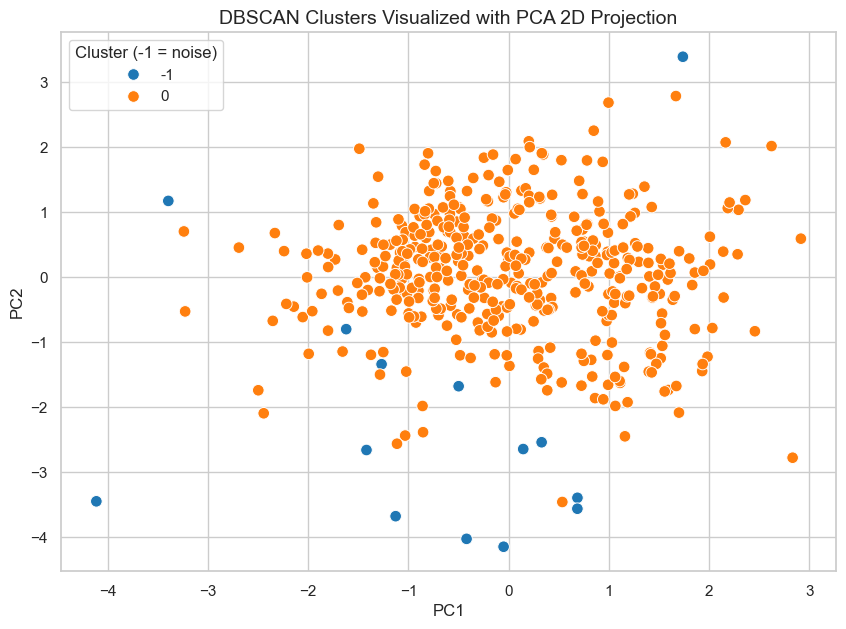

In [126]:
# PCA 2D visualization of DBSCAN clusters
pca_plot_df["DBSCAN_Cluster"] = dbscan_labels

plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_plot_df, x="PC1", y="PC2", hue="DBSCAN_Cluster", palette="tab10", s=70)
plt.title("DBSCAN Clusters Visualized with PCA 2D Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster (-1 = noise)")
plt.show()

In [127]:
# DBSCAN evaluation, ignoring noise for the internal metrics
sil_dbscan, dbi_dbscan, n_clusters_dbscan_eval, dbscan_valid = evaluate_labels(
    X_processed, dbscan_labels, ignore_noise=True
)

print("DBSCAN valid metrics:", dbscan_valid)
print("DBSCAN silhouette score without noise:", sil_dbscan)
print("DBSCAN Davies-Bouldin index without noise:", dbi_dbscan)

DBSCAN valid metrics: False
DBSCAN silhouette score without noise: nan
DBSCAN Davies-Bouldin index without noise: nan


## PART 4 — Clustering with DBSCAN

### 1. What are the main parameters of DBSCAN?

The main parameters of DBSCAN are:

- **eps**: the maximum distance between points for them to be considered neighbors.
- **min_samples**: the minimum number of points required to form a dense region.

In this notebook:

- **min_samples = 12**
- **eps = 1.5910899627216921**

### 2. Explain core points, border points, and noise.

In DBSCAN, points are classified into three types:

A **core point** is a point that has at least `min_samples` neighbors within distance `eps`.

A **border point** is not dense enough to be a core point, but it is close to a core point.

A **noise point** is a point that does not belong to any dense region. Noise points are labeled as **-1**.

In this project, DBSCAN detected **14 noise points**.

### 3. How did you choose eps and min_samples?

The value of `min_samples` was chosen as:

**2 × number of features = 2 × 6 = 12**

This is a common starting rule for DBSCAN.

The value of `eps` was selected using the k-distance plot and candidate eps values. The final selected value was:

**eps = 1.5910899627216921**

This value came from the distance curve and was used to fit the final DBSCAN model.

### 4. Compare DBSCAN with K-Means.

K-Means produced **2 useful clusters** with a valid silhouette score of **0.253846**.

DBSCAN found:

| Label | Number of customers |
|---|---:|
| Noise (-1) | 14 |
| Cluster 0 | 426 |

So DBSCAN produced only **one main cluster** and **14 noise points**.

Because there was only one main cluster after ignoring noise, the DBSCAN metrics were invalid:

- Silhouette Score: **NaN**
- Davies-Bouldin Index: **NaN**

DBSCAN was useful for detecting noise points, but it did not produce meaningful multiple clusters for this dataset using the selected parameters. In this project, K-Means was more useful than DBSCAN for customer segmentation.

---


# PART 5 — Hierarchical Clustering

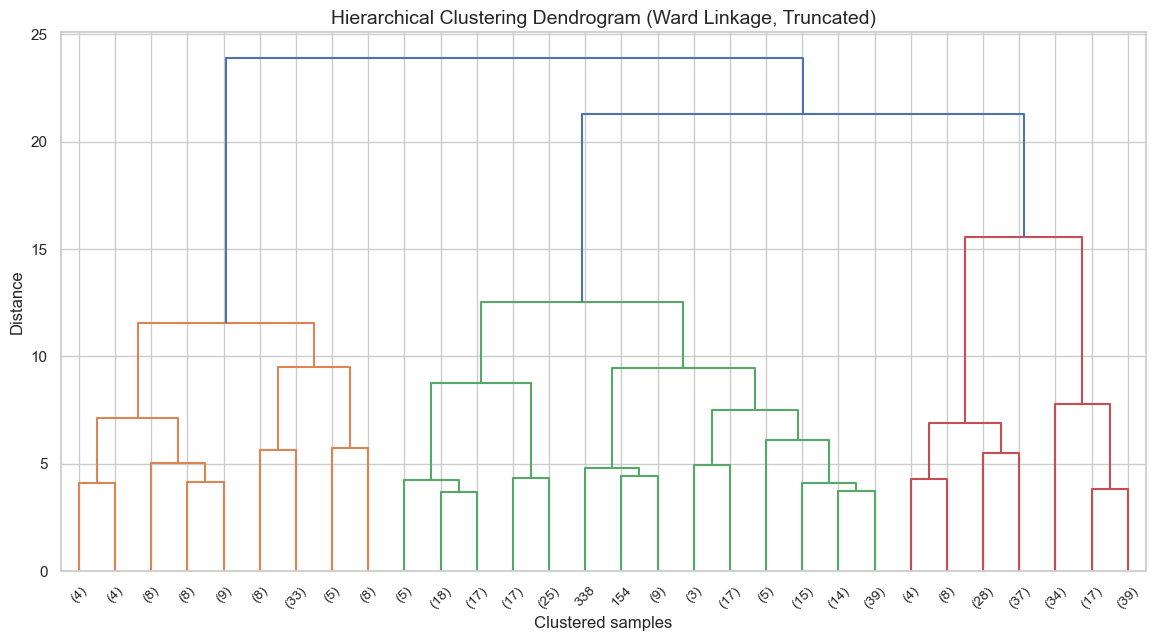

In [128]:
# Create a linkage matrix for hierarchical clustering
linkage_matrix = linkage(X_processed, method="ward")

# Dendrogram visualization
plt.figure(figsize=(14, 7))
dendrogram(linkage_matrix, truncate_mode="lastp", p=30, leaf_rotation=45, leaf_font_size=10)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage, Truncated)")
plt.xlabel("Clustered samples")
plt.ylabel("Distance")
plt.show()

In [129]:
# Try several numbers of clusters and evaluate with silhouette score
hierarchical_rows = []

for k in range(2, 11):
    model = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = model.fit_predict(X_processed)
    sil = silhouette_score(X_processed, labels)
    dbi = davies_bouldin_score(X_processed, labels)
    hierarchical_rows.append({
        "Number of clusters": k,
        "Silhouette Score": sil,
        "Davies-Bouldin Index": dbi
    })

hierarchical_scores_df = pd.DataFrame(hierarchical_rows)
display(hierarchical_scores_df)

,Number of clusters,Silhouette Score,Davies-Bouldin Index
0,2,0.254408,1.552662
1,3,0.174983,1.588859
2,4,0.142597,1.518350
3,5,0.145875,1.661237
4,6,0.157238,1.615209
5,7,0.153162,1.523548
6,8,0.158169,1.462689
7,9,0.164275,1.396989
8,10,0.137367,1.457900


In [130]:
# Select the number of clusters with the highest silhouette score.
# You can adjust this after interpreting the dendrogram.
optimal_hierarchical_k = int(
    hierarchical_scores_df.loc[hierarchical_scores_df["Silhouette Score"].idxmax(), "Number of clusters"]
)
print("Optimal hierarchical K selected from silhouette score:", optimal_hierarchical_k)

hierarchical_final = AgglomerativeClustering(n_clusters=optimal_hierarchical_k, linkage="ward")
hierarchical_labels = hierarchical_final.fit_predict(X_processed)
analysis_df["Hierarchical_Cluster"] = hierarchical_labels

print("Hierarchical cluster counts:")
display(analysis_df["Hierarchical_Cluster"].value_counts().sort_index().to_frame("Count"))

Optimal hierarchical K selected from silhouette score: 2
Hierarchical cluster counts:


,Count
Hierarchical_Cluster,
0,353
1,87


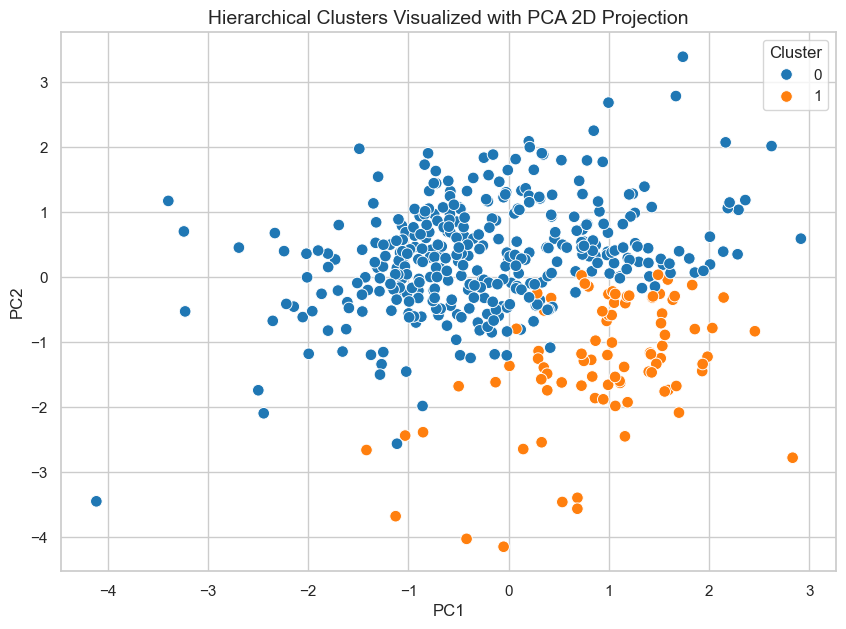

In [131]:
# PCA 2D visualization of hierarchical clusters
pca_plot_df["Hierarchical_Cluster"] = hierarchical_labels

plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_plot_df, x="PC1", y="PC2", hue="Hierarchical_Cluster", palette="tab10", s=70)
plt.title("Hierarchical Clusters Visualized with PCA 2D Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.show()

In [132]:
# Hierarchical clustering profile table
hierarchical_profile = analysis_df.groupby("Hierarchical_Cluster")[spending_features].mean().round(2)
hierarchical_profile["Cluster Size"] = analysis_df["Hierarchical_Cluster"].value_counts().sort_index()

display(hierarchical_profile)

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Cluster Size
Hierarchical_Cluster,,,,,,,
0,14197.66,5256.91,6403.86,3647.99,2033.04,1644.30,353
1,3084.55,7984.68,14229.86,734.60,6324.07,1040.28,87


## PART 5 — Hierarchical Clustering

### 1. What is hierarchical clustering?

Hierarchical clustering is a clustering method that builds a hierarchy of clusters.

In this project, Agglomerative Clustering was used. This is a bottom-up method. It starts with each customer as its own cluster, then gradually merges the closest clusters together until the selected number of clusters is reached.

The notebook used **Ward linkage**, which tries to merge clusters in a way that minimizes the increase in within-cluster variance.

### 2. What is a dendrogram?

A dendrogram is a tree-like diagram that shows how clusters are merged step by step.

In the dendrogram:

- The leaves represent individual samples or small groups.
- The branches show how clusters are combined.
- The vertical distance shows how different the merged clusters are.

Large vertical gaps in the dendrogram can help decide a good number of clusters.

### 3. How do you decide the number of clusters?

The number of clusters was selected using the dendrogram and evaluation metrics.

The hierarchical clustering scores were:

| Number of clusters | Silhouette Score | Davies-Bouldin Index |
|---:|---:|---:|
| 2 | 0.254408 | 1.552662 |
| 3 | 0.174983 | 1.588859 |
| 4 | 0.142597 | 1.518350 |
| 5 | 0.145875 | 1.661237 |
| 6 | 0.157238 | 1.615209 |
| 7 | 0.153162 | 1.523548 |
| 8 | 0.158169 | 1.462689 |
| 9 | 0.164275 | 1.396989 |
| 10 | 0.137367 | 1.457900 |

The best silhouette score was obtained with **2 clusters**, with a score of **0.254408**.

The final hierarchical cluster counts were:

| Cluster | Number of customers |
|---|---:|
| Cluster 0 | 353 |
| Cluster 1 | 87 |

The profile showed that:

- **Cluster 0** has higher Fresh, Frozen, and Delicassen spending.
- **Cluster 1** has lower Fresh and Frozen spending, but higher Milk, Grocery, and Detergents_Paper spending.

Therefore, the selected number of clusters for Hierarchical Clustering was **2**.

---

# PART 6 — Dimensionality Reduction

In [133]:
# PCA with all components to inspect explained variance
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_processed)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

pca_variance_df = pd.DataFrame({
    "Component": np.arange(1, len(explained_variance) + 1),
    "Explained Variance Ratio": explained_variance,
    "Cumulative Explained Variance": cumulative_variance
})

display(pca_variance_df)

# Number of components needed to explain at least 90% of variance
n_components_90 = int(np.argmax(cumulative_variance >= 0.90) + 1)
print("Number of PCA components needed for at least 90% variance:", n_components_90)

,Component,Explained Variance Ratio,Cumulative Explained Variance
0,1,0.363362,0.363362
1,2,0.332007,0.695369
2,3,0.127197,0.822566
3,4,0.117231,0.939797
4,5,0.037892,0.977688
5,6,0.022312,1.000000


Number of PCA components needed for at least 90% variance: 4


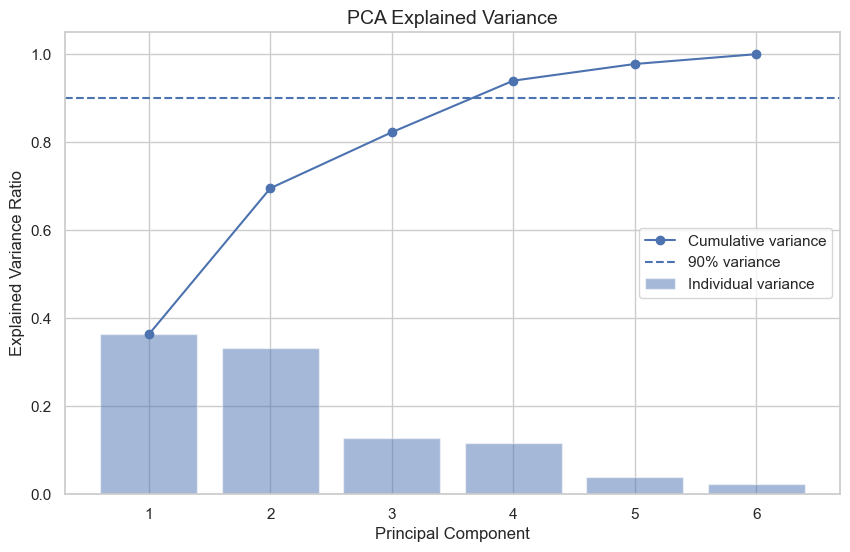

In [134]:
# Explained variance plot
plt.figure(figsize=(10, 6))
plt.plot(pca_variance_df["Component"], pca_variance_df["Cumulative Explained Variance"], marker="o", label="Cumulative variance")
plt.bar(pca_variance_df["Component"], pca_variance_df["Explained Variance Ratio"], alpha=0.5, label="Individual variance")
plt.axhline(0.90, linestyle="--", label="90% variance")
plt.title("PCA Explained Variance")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.xticks(pca_variance_df["Component"])
plt.legend()
plt.show()

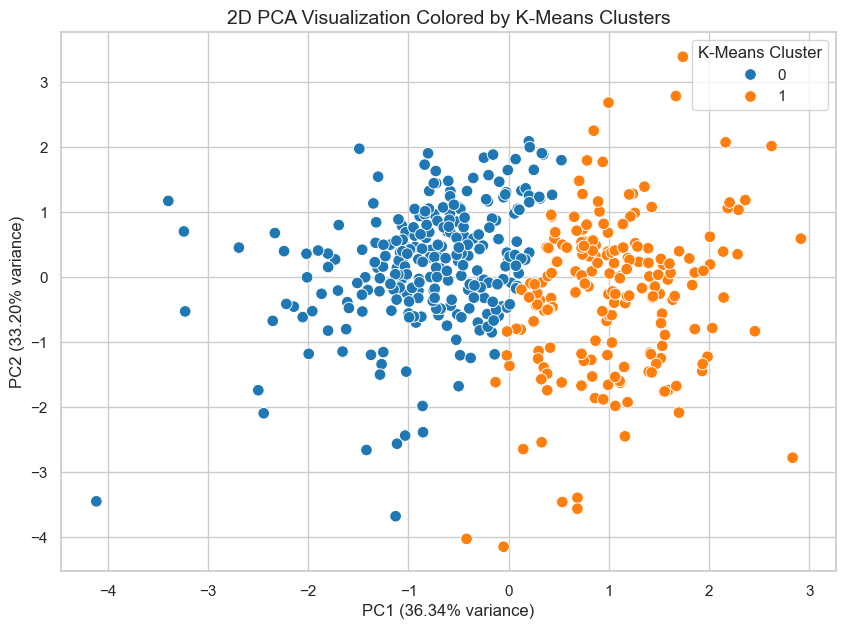

In [135]:
# 2D PCA visualization colored with K-Means labels
plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_plot_df, x="PC1", y="PC2", hue="KMeans_Cluster", palette="tab10", s=70)
plt.title("2D PCA Visualization Colored by K-Means Clusters")
plt.xlabel(f"PC1 ({pca_2d_model.explained_variance_ratio_[0]*100:.2f}% variance)")
plt.ylabel(f"PC2 ({pca_2d_model.explained_variance_ratio_[1]*100:.2f}% variance)")
plt.legend(title="K-Means Cluster")
plt.show()

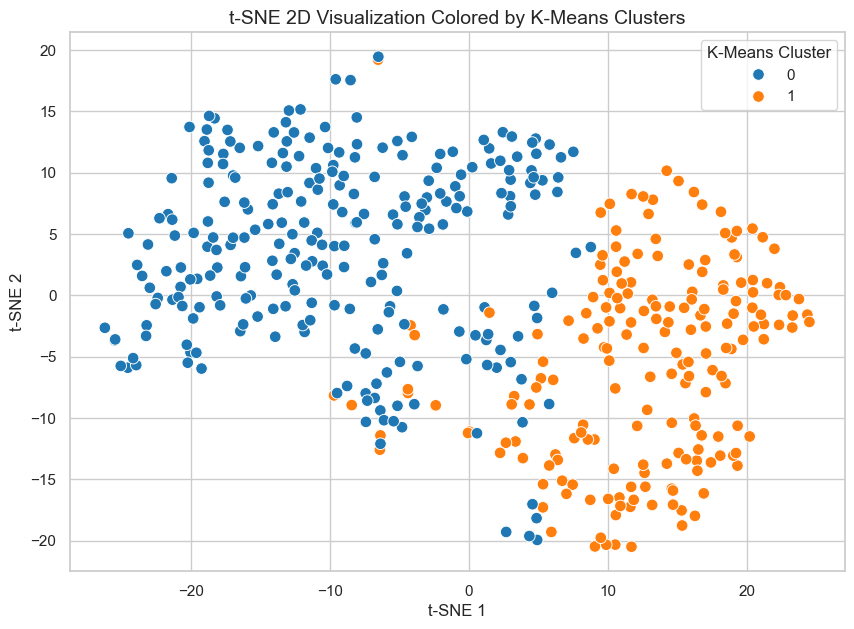

In [136]:
# t-SNE 2D visualization
# Perplexity should be smaller than the number of samples.
tsne_perplexity = min(30, max(5, (len(X_processed) - 1) // 3))

tsne_model = TSNE(
    n_components=2,
    perplexity=tsne_perplexity,
    learning_rate="auto",
    init="pca",
    random_state=RANDOM_STATE
)
tsne_2d = tsne_model.fit_transform(X_processed)

tsne_df = pd.DataFrame(tsne_2d, columns=["tSNE1", "tSNE2"], index=df.index)
tsne_df["KMeans_Cluster"] = kmeans_labels

plt.figure(figsize=(10, 7))
sns.scatterplot(data=tsne_df, x="tSNE1", y="tSNE2", hue="KMeans_Cluster", palette="tab10", s=70)
plt.title("t-SNE 2D Visualization Colored by K-Means Clusters")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="K-Means Cluster")
plt.show()

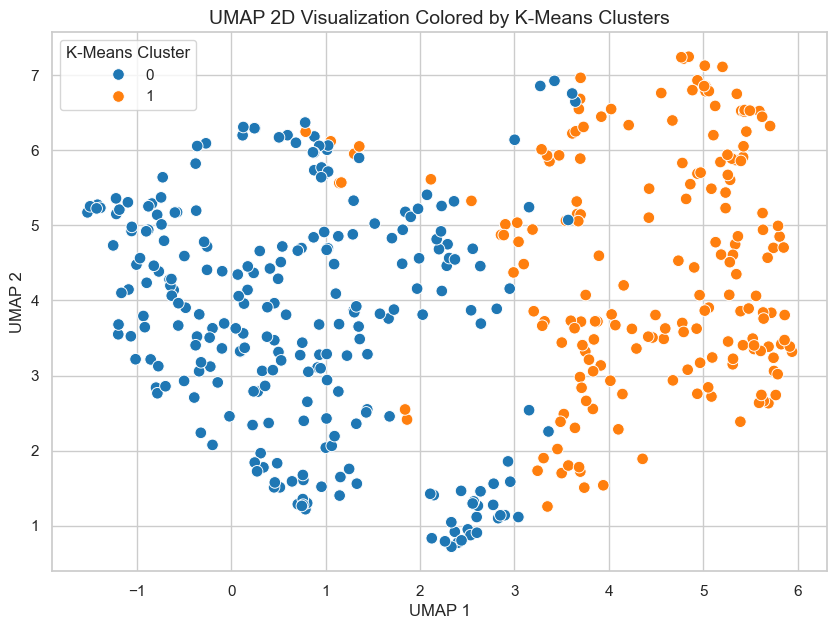

In [137]:
# UMAP 2D visualization
# If UMAP is not installed, run: pip install umap-learn
try:
    import umap.umap_ as umap

    umap_model = umap.UMAP(n_components=2, random_state=RANDOM_STATE)
    umap_2d = umap_model.fit_transform(X_processed)

    umap_df = pd.DataFrame(umap_2d, columns=["UMAP1", "UMAP2"], index=df.index)
    umap_df["KMeans_Cluster"] = kmeans_labels

    plt.figure(figsize=(10, 7))
    sns.scatterplot(data=umap_df, x="UMAP1", y="UMAP2", hue="KMeans_Cluster", palette="tab10", s=70)
    plt.title("UMAP 2D Visualization Colored by K-Means Clusters")
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.legend(title="K-Means Cluster")
    plt.show()
except ImportError:
    print("UMAP is not installed. To enable this section, run: pip install umap-learn")

## PART 6 — Dimensionality Reduction

### 1. Why do we use dimensionality reduction?

Dimensionality reduction is used to reduce the number of features while keeping as much important information as possible.

In this project, the original data has 6 spending features. Reducing it to 2 dimensions helps visualize the customer clusters on a scatter plot.

Dimensionality reduction is also useful because it can make patterns easier to understand and can sometimes reduce noise in the data.

### 2. What is the difference between PCA, UMAP, and t-SNE?

**PCA** is a linear dimensionality reduction method. It finds new axes called principal components that explain the maximum variance in the data. PCA is useful for understanding variance and can be used for both visualization and feature reduction.

**t-SNE** is a nonlinear method mainly used for visualization. It tries to keep similar points close together in 2D space. It is good for visualizing local structure, but it is not usually used as a preprocessing step for modeling.

**UMAP** is also a nonlinear method. It is often faster than t-SNE and can preserve both local and some global structure. UMAP was also applied successfully to create a 2D visualization of the customer data. Like t-SNE, UMAP is a nonlinear dimensionality reduction method, and it helped visualize the cluster structure in two dimensions.

### 3. How many components do you keep in PCA? Why?

The PCA explained variance results were:

| Component | Explained Variance Ratio | Cumulative Explained Variance |
|---:|---:|---:|
| PC1 | 0.363362 | 0.363362 |
| PC2 | 0.332007 | 0.695369 |
| PC3 | 0.127197 | 0.822566 |
| PC4 | 0.117231 | 0.939797 |
| PC5 | 0.037892 | 0.977688 |
| PC6 | 0.022312 | 1.000000 |

To keep at least **90% of the variance**, we need **4 PCA components**.

The first 4 components explain about **93.98%** of the total variance.

For visualization, only 2 components were used. The 2D PCA projection explains about:

**69.54% of the variance**

This is enough for visualization, but not enough to represent all information perfectly.

### 4. Does PCA help visualize clusters?

Yes, PCA helped visualize the clusters in 2D.

The PCA scatter plots showed that the clusters have some separation, especially along the first principal component. However, the separation is not perfect, which is consistent with the moderate silhouette scores.

So PCA is useful for visualization, but the clusters still overlap in some areas.

---

# PART 7 — Clustering Evaluation

In [138]:
# Evaluate K-Means, DBSCAN, and Hierarchical Clustering
sil_kmeans, dbi_kmeans, n_clusters_kmeans, valid_kmeans = evaluate_labels(X_processed, kmeans_labels, ignore_noise=False)
sil_hier, dbi_hier, n_clusters_hier, valid_hier = evaluate_labels(X_processed, hierarchical_labels, ignore_noise=False)
sil_dbscan, dbi_dbscan, n_clusters_dbscan_eval, valid_dbscan_metrics = evaluate_labels(X_processed, dbscan_labels, ignore_noise=True)

comparison_rows = [
    {
        "Method": "K-Means",
        "Number of clusters": n_clusters_kmeans,
        "Silhouette Score": sil_kmeans,
        "Davies-Bouldin Index": dbi_kmeans,
        "Noise points": 0,
        "Metrics valid": valid_kmeans,
        "Interpretation": "Produced 2 useful clusters and performed very close to hierarchical clustering."
    },
    {
        "Method": "DBSCAN",
        "Number of clusters": n_clusters_dbscan_eval,
        "Silhouette Score": sil_dbscan,
        "Davies-Bouldin Index": dbi_dbscan,
        "Noise points": noise_count_dbscan,
        "Metrics valid": valid_dbscan_metrics,
        "Interpretation": "Detected 14 noise points but found only one main cluster, so metrics were invalid."
    },
    {
        "Method": "Hierarchical Clustering",
        "Number of clusters": n_clusters_hier,
        "Silhouette Score": sil_hier,
        "Davies-Bouldin Index": dbi_hier,
        "Noise points": 0,
        "Metrics valid": valid_hier,
        "Interpretation": "Best valid silhouette score and selected for final business interpretation."
    }
]

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

,Method,Number of clusters,Silhouette Score,Davies-Bouldin Index,Noise points,Metrics valid,Interpretation
0,K-Means,2,0.253846,1.540483,0,True,Produced 2 useful clusters and performed very ...
1,DBSCAN,1,NaN,NaN,14,False,Detected 14 noise points but found only one ma...
2,Hierarchical Clustering,2,0.254408,1.552662,0,True,Best valid silhouette score and selected for f...


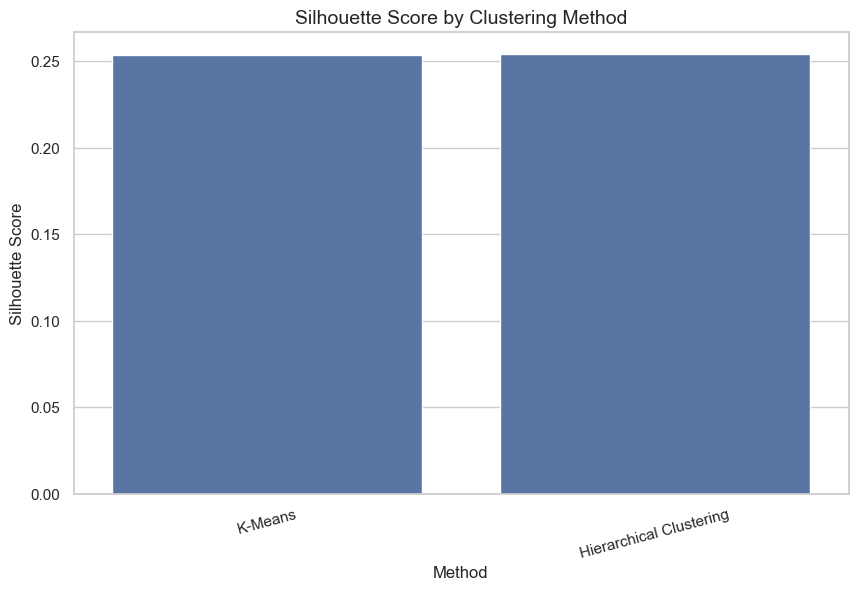

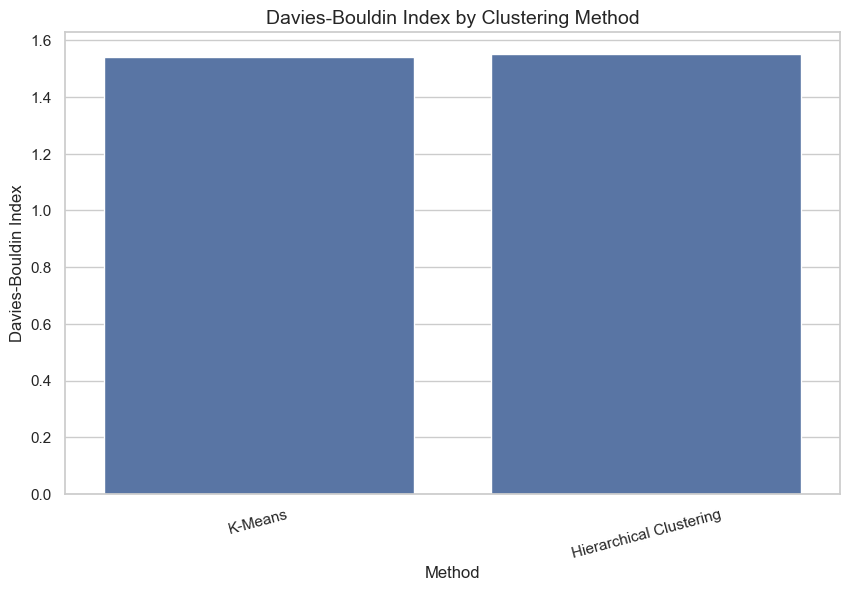

In [139]:
# Bar chart comparison of evaluation metrics
valid_comparison = comparison_df[comparison_df["Metrics valid"] == True].copy()

plt.figure(figsize=(10, 6))
sns.barplot(data=valid_comparison, x="Method", y="Silhouette Score", color="C0")
plt.title("Silhouette Score by Clustering Method")
plt.xlabel("Method")
plt.ylabel("Silhouette Score")
plt.xticks(rotation=15)
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=valid_comparison, x="Method", y="Davies-Bouldin Index", color="C0")
plt.title("Davies-Bouldin Index by Clustering Method")
plt.xlabel("Method")
plt.ylabel("Davies-Bouldin Index")
plt.xticks(rotation=15)
plt.show()

## PART 7 — Clustering Evaluation

### 1. Why is clustering evaluation difficult?

Clustering evaluation is difficult because this is an unsupervised learning problem.

There are no true labels telling us the correct customer group for each customer. Because of this, we cannot use supervised metrics like accuracy, precision, or recall.

Instead, we use internal evaluation metrics such as:

- **Silhouette Score**
- **Davies-Bouldin Index**

These metrics help estimate cluster quality, but they do not always fully represent business usefulness.

### 2. Compute Silhouette Score and Davies-Bouldin Index.

The clustering evaluation results were:

| Method | Number of clusters | Silhouette Score | Davies-Bouldin Index | Notes |
|---|---:|---:|---:|---|
| K-Means | 2 | 0.253846 | 1.540483 | Valid metrics |
| DBSCAN | 1 | NaN | NaN | Invalid metrics because only one main cluster was found after ignoring noise |
| Hierarchical Clustering | 2 | 0.254408 | 1.552662 | Valid metrics |

DBSCAN metrics were invalid because Silhouette Score and Davies-Bouldin Index require at least two clusters. DBSCAN found only one main cluster and 14 noise points.

### 3. Which method performs best?

According to the valid silhouette scores, **Hierarchical Clustering** performed best.

It achieved a silhouette score of:

**0.254408**

This is slightly higher than K-Means, which had:

**0.253846**

However, the difference is very small. This means both K-Means and Hierarchical Clustering gave similar clustering quality, but Hierarchical Clustering was selected as the best method according to the notebook’s valid silhouette score.

---

# PART 8 — Model Comparison

In [140]:
# Final model comparison table required by the lab
model_comparison_table = comparison_df[[
    "Method", "Number of clusters", "Silhouette Score", "Davies-Bouldin Index", "Interpretation"
]].copy()

# Sort by Silhouette Score descending, while keeping invalid/NaN rows at the bottom
model_comparison_table = model_comparison_table.sort_values(
    by="Silhouette Score", ascending=False, na_position="last"
).reset_index(drop=True)

display(model_comparison_table)

,Method,Number of clusters,Silhouette Score,Davies-Bouldin Index,Interpretation
0,Hierarchical Clustering,2,0.254408,1.552662,Best valid silhouette score and selected for f...
1,K-Means,2,0.253846,1.540483,Produced 2 useful clusters and performed very ...
2,DBSCAN,1,NaN,NaN,Detected 14 noise points but found only one ma...


In [141]:
# Automatically identify the best method according to silhouette score among valid methods.
if len(valid_comparison) > 0:
    best_method = valid_comparison.loc[valid_comparison["Silhouette Score"].idxmax(), "Method"]
else:
    best_method = "K-Means"

print("Best method according to valid silhouette score:", best_method)

Best method according to valid silhouette score: Hierarchical Clustering


## PART 8 — Model Comparison

| Method | Number of clusters | Silhouette Score | Davies-Bouldin Index | Interpretation |
|---|---:|---:|---:|---|
| Hierarchical Clustering | 2 | 0.254408 | 1.552662 | Best valid silhouette score; selected for final business interpretation |
| K-Means | 2 | 0.253846 | 1.540483 | Very close to Hierarchical Clustering and produced useful clusters |
| DBSCAN | 1 | NaN | NaN | Not suitable here because it found only one main cluster and 14 noise points |

### 1. Which method is the best?

The best method according to the valid silhouette score is **Hierarchical Clustering**.

It produced **2 clusters** and achieved the highest silhouette score:

**0.254408**

K-Means was very close, but Hierarchical Clustering was ranked first in the comparison table.

DBSCAN was not selected because it produced only one main cluster and 14 noise points, so its evaluation metrics were invalid.

### 2. Is K-Means always suitable? Why?

No, K-Means is not always suitable.

K-Means works best when clusters are relatively compact, spherical, and similar in size. It also requires choosing the number of clusters K before training.

K-Means is sensitive to outliers because outliers can affect the position of the centroids. It may also perform poorly when clusters have irregular or non-spherical shapes.

In this project, K-Means worked reasonably well and produced two useful clusters, but Hierarchical Clustering gave a slightly better silhouette score.

---

# PART 9 — Critical Analysis

## PART 9 — Critical Analysis

### 1. What are the limitations of K-Means?

The main limitations of K-Means are:

- It requires choosing the number of clusters K before training.
- It assumes clusters are roughly spherical.
- It is sensitive to outliers.
- It may not work well with clusters of different densities or irregular shapes.
- The final result can depend on the initialization of centroids.

In this project, K-Means produced useful clusters, but the silhouette score was only **0.253846**, which means the clusters were only moderately separated.

### 2. Difference between K-Means vs DBSCAN.

K-Means is a centroid-based method. It divides customers into a fixed number of clusters based on distance to centroids.

DBSCAN is a density-based method. It groups points that are close together in dense regions and labels isolated points as noise.

In this project:

- K-Means produced **2 useful clusters**.
- DBSCAN detected **14 noise points**, but found only **one main cluster**.
- DBSCAN metrics were invalid because it did not produce at least two meaningful clusters after ignoring noise.

So, K-Means was better for segmentation here, while DBSCAN was mainly useful for detecting noise.

### 3. Difference between centroid-based vs density-based clustering.

Centroid-based clustering, such as K-Means, creates clusters around central points called centroids. Each point is assigned to the nearest centroid.

Density-based clustering, such as DBSCAN, creates clusters based on dense areas of points. It does not require specifying the number of clusters in advance and can detect noise.

Centroid-based methods are usually better for compact and regular clusters. Density-based methods are better when clusters have irregular shapes or when there is noise.

### 4. Which method handles noise better?

DBSCAN handles noise better.

In this project, DBSCAN identified **14 noise points**, labeled as **-1**.

K-Means and Hierarchical Clustering assign every customer to a cluster, even if the customer is unusual. DBSCAN is different because it can separate unusual points as noise.

### 5. Which method can detect non-spherical clusters?

DBSCAN can detect non-spherical clusters better than K-Means.

K-Means usually works best with spherical or compact clusters. DBSCAN can find clusters with more irregular shapes because it is based on density.

However, in this dataset, DBSCAN did not produce multiple meaningful clusters using the selected parameters.

---


# PART 10 — Business Interpretation

In [142]:
# Select final labels based on the best method from Part 8.
label_options = {
    "K-Means": kmeans_labels,
    "DBSCAN": dbscan_labels,
    "Hierarchical Clustering": hierarchical_labels
}

final_labels = label_options.get(best_method, kmeans_labels)
analysis_df["Final_Cluster"] = final_labels

print("Final method used for business interpretation:", best_method)
print("Final cluster counts:")
display(analysis_df["Final_Cluster"].value_counts().sort_index().to_frame("Count"))

Final method used for business interpretation: Hierarchical Clustering
Final cluster counts:


,Count
Final_Cluster,
0,353
1,87


In [143]:
# Final cluster profile table: average annual spending per product category
final_cluster_profile = analysis_df.groupby("Final_Cluster")[spending_features].mean().round(2)
final_cluster_profile["Cluster Size"] = analysis_df["Final_Cluster"].value_counts().sort_index()
final_cluster_profile["Total Average Spending"] = final_cluster_profile[spending_features].sum(axis=1).round(2)

display(final_cluster_profile)

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Cluster Size,Total Average Spending
Final_Cluster,,,,,,,,
0,14197.66,5256.91,6403.86,3647.99,2033.04,1644.30,353,33183.76
1,3084.55,7984.68,14229.86,734.60,6324.07,1040.28,87,33398.04


In [144]:
# Relative profile table: each cluster average divided by the global average.
# Values above 1 mean the cluster spends more than average in that category.
global_average = analysis_df[spending_features].mean()
relative_cluster_profile = final_cluster_profile[spending_features].div(global_average, axis=1).round(2)

display(relative_cluster_profile)

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Final_Cluster,,,,,,
0,1.18,0.91,0.81,1.19,0.71,1.08
1,0.26,1.38,1.79,0.24,2.19,0.68


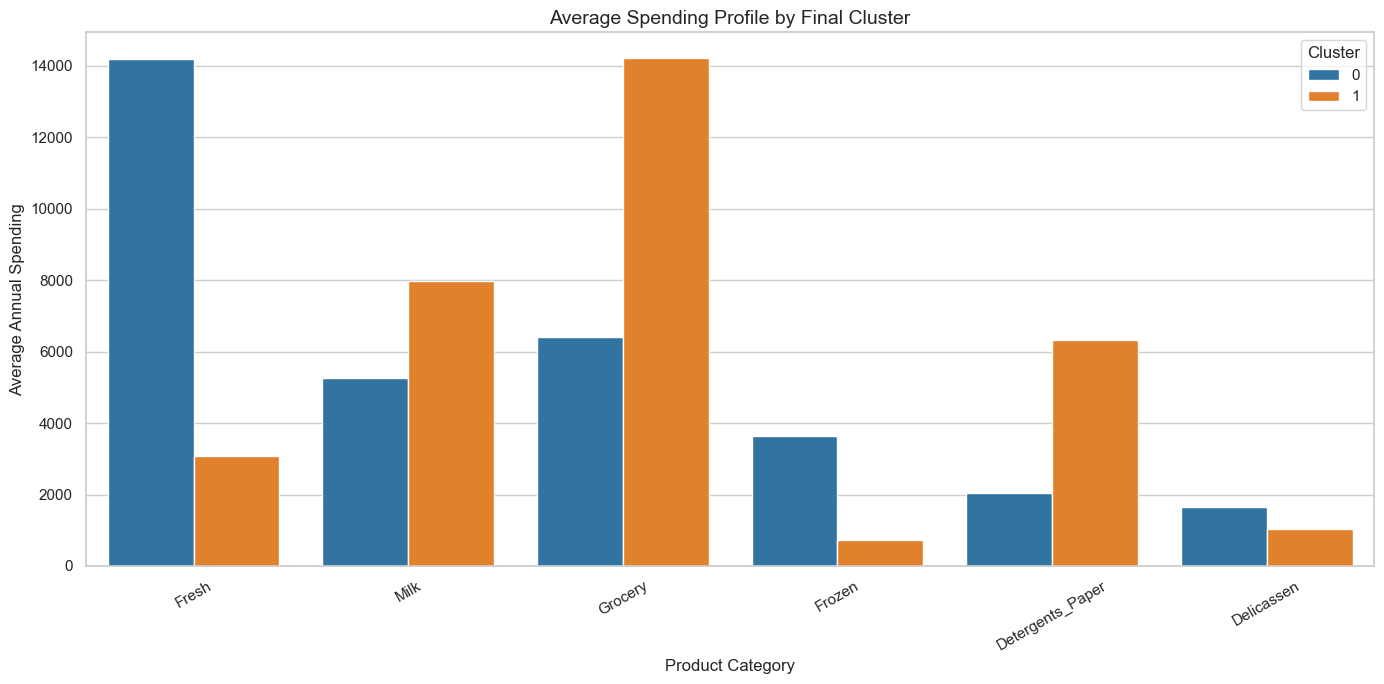

In [145]:
# Bar chart of average spending by cluster
profile_for_plot = final_cluster_profile[spending_features].reset_index().melt(
    id_vars="Final_Cluster",
    var_name="Product Category",
    value_name="Average Spending"
)

plt.figure(figsize=(14, 7))
sns.barplot(data=profile_for_plot, x="Product Category", y="Average Spending", hue="Final_Cluster", palette="tab10")
plt.title("Average Spending Profile by Final Cluster")
plt.xlabel("Product Category")
plt.ylabel("Average Annual Spending")
plt.xticks(rotation=30)
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

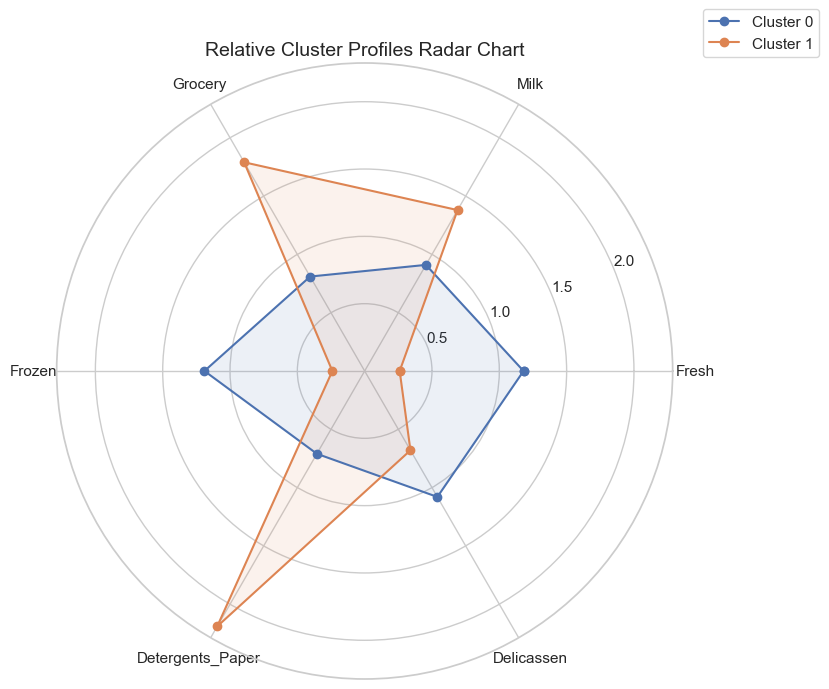

In [146]:
#radar chart for cluster profiles
# This plot uses normalized relative values for easier comparison.
def plot_radar_chart(relative_profile):
    categories = relative_profile.columns.tolist()
    angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    for cluster_id, row in relative_profile.iterrows():
        values = row.tolist()
        values += values[:1]
        ax.plot(angles, values, marker="o", label=f"Cluster {cluster_id}")
        ax.fill(angles, values, alpha=0.10)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)
    ax.set_title("Relative Cluster Profiles Radar Chart")
    ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.10))
    plt.show()

plot_radar_chart(relative_cluster_profile)

In [147]:
#table for writing business names and strategies.
business_interpretation_table = final_cluster_profile.copy()

business_interpretation_table["Suggested Cluster Name"] = [
    "Fresh and Frozen Oriented Customers",
    "Grocery, Milk, and Detergents Focused Customers"
]

business_interpretation_table["Business Strategy"] = [
    "Focus on fresh and frozen product quality, fast delivery, loyalty offers, and bundles with delicatessen products.",
    "Offer bulk discounts on grocery, milk, and detergents, with targeted promotions and regular restocking plans."
]

display(business_interpretation_table)

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Cluster Size,Total Average Spending,Suggested Cluster Name,Business Strategy
Final_Cluster,,,,,,,,,,
0,14197.66,5256.91,6403.86,3647.99,2033.04,1644.30,353,33183.76,Fresh and Frozen Oriented Customers,"Focus on fresh and frozen product quality, fas..."
1,3084.55,7984.68,14229.86,734.60,6324.07,1040.28,87,33398.04,"Grocery, Milk, and Detergents Focused Customers","Offer bulk discounts on grocery, milk, and det..."


## PART 10 — Business Interpretation

The final selected method for business interpretation was:

**Hierarchical Clustering**

It produced **2 clusters**:

| Cluster | Number of customers |
|---|---:|
| Cluster 0 | 353 |
| Cluster 1 | 87 |

### 1. Describe each cluster as a customer profile.

#### Cluster 0 — Fresh and Frozen Oriented Customers

Cluster 0 contains **353 customers**.

Average spending profile:

| Feature | Average spending |
|---|---:|
| Fresh | 14197.66 |
| Milk | 5256.91 |
| Grocery | 6403.86 |
| Frozen | 3647.99 |
| Detergents_Paper | 2033.04 |
| Delicassen | 1644.30 |
| Total Average Spending | 33183.76 |

Relative profile:

| Feature | Relative value |
|---|---:|
| Fresh | 1.18 |
| Milk | 0.91 |
| Grocery | 0.81 |
| Frozen | 1.19 |
| Detergents_Paper | 0.71 |
| Delicassen | 1.08 |

This group spends more than average on **Fresh**, **Frozen**, and **Delicassen** products. It spends less than average on **Grocery**, **Milk**, and especially **Detergents_Paper**.

This cluster may represent customers such as restaurants, food service businesses, or customers focused on fresh and frozen food products.

#### Cluster 1 — Grocery, Milk, and Detergents Focused Customers

Cluster 1 contains **87 customers**.

Average spending profile:

| Feature | Average spending |
|---|---:|
| Fresh | 3084.55 |
| Milk | 7984.68 |
| Grocery | 14229.86 |
| Frozen | 734.60 |
| Detergents_Paper | 6324.07 |
| Delicassen | 1040.28 |
| Total Average Spending | 33398.04 |

Relative profile:

| Feature | Relative value |
|---|---:|
| Fresh | 0.26 |
| Milk | 1.38 |
| Grocery | 1.79 |
| Frozen | 0.24 |
| Detergents_Paper | 2.19 |
| Delicassen | 0.68 |

This group spends much more than average on **Grocery**, **Milk**, and **Detergents_Paper**. It spends much less than average on **Fresh** and **Frozen** products.

This cluster may represent customers such as retail stores, supermarkets, or shops that buy packaged goods, cleaning products, and dairy products.

### 2. Give names to the clusters.

The suggested cluster names are:

| Cluster | Suggested name |
|---|---|
| Cluster 0 | Fresh and Frozen Oriented Customers |
| Cluster 1 | Grocery, Milk, and Detergents Focused Customers |

### 3. What strategy should the company apply to each group?

#### Strategy for Cluster 0 — Fresh and Frozen Oriented Customers

For this group, the company should focus on fresh and frozen product supply.

Recommended strategies:

- Offer discounts or loyalty programs for Fresh and Frozen products.
- Provide reliable and fast delivery because fresh products are time-sensitive.
- Promote bundles that combine Fresh, Frozen, and Delicassen products.
- Focus on product quality and freshness.
- Build long-term contracts with customers who need regular fresh food supply.

#### Strategy for Cluster 1 — Grocery, Milk, and Detergents Focused Customers

For this group, the company should focus on grocery, dairy, and detergent products.

Recommended strategies:

- Offer bulk discounts on Grocery and Detergents_Paper products.
- Create special promotions for Milk and Grocery combinations.
- Recommend high-volume packaged goods.
- Provide restocking plans for shops and supermarkets.
- Use targeted marketing campaigns for cleaning products and dairy products.

---

---
## Final Conclusion

In this project, the Wholesale Customers Dataset was used to perform customer segmentation using unsupervised learning.

The dataset contained **440 customers** and **8 columns**. The clustering process used the 6 spending features:

- **Fresh**
- **Milk**
- **Grocery**
- **Frozen**
- **Detergents_Paper**
- **Delicassen**

The data had no missing values or duplicate rows, but it contained strong skewness and several outliers. To prepare the data, a log transformation was applied, extreme outliers were clipped carefully, and RobustScaler was used.

Three clustering methods were tested:

| Method | Result |
|---|---|
| K-Means | Produced 2 useful clusters with silhouette score 0.253846 |
| DBSCAN | Found 1 main cluster and 14 noise points, so metrics were invalid |
| Hierarchical Clustering | Produced 2 clusters with the best silhouette score 0.254408 |

The best method according to the valid silhouette score was **Hierarchical Clustering**.

The final segmentation produced two customer profiles:

- **Cluster 0: Fresh and Frozen Oriented Customers**
- **Cluster 1: Grocery, Milk, and Detergents Focused Customers**

This segmentation is useful for the business because it helps the distributor understand different customer purchasing behaviors. The company can use these clusters to create targeted promotions, improve stock management, personalize offers, and build better customer strategies.

However, the silhouette scores were moderate, which means the clusters are not perfectly separated. Also, DBSCAN did not work well for this dataset using the selected parameters. Therefore, the results should be interpreted carefully and can be improved later using more features, business knowledge, or additional clustering experiments.